In [1]:
import numpy as np
import pandas as pd

In [2]:
#Read the CSV file using Latin-1 character encoding to correctly interpret special characters.
df = pd.read_csv('spam.csv', encoding='latin-1')

In [14]:
df.sample(20)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
3346,ham,No problem baby. Is this is a good time to tal...,NaN,NaN,NaN
1726,ham,\ALRITE HUNNY!WOT U UP 2 2NITE? DIDNT END UP G...,NaN,NaN,NaN
730,spam,Email AlertFrom: Jeri StewartSize: 2KBSubject:...,NaN,NaN,NaN
671,spam,SMS. ac sun0819 posts HELLO:\You seem cool,"wanted to say hi. HI!!!\"" Stop? Send STOP to ...",NaN,NaN
780,ham,Your opinion about me? 1. Over 2. Jada 3. Kusr...,NaN,NaN,NaN
2232,ham,Nothing just getting msgs by dis name wit diff...,NaN,NaN,NaN
1022,ham,We still on for tonight?,NaN,NaN,NaN
300,ham,"Awesome, I remember the last time we got someb...",NaN,NaN,NaN
1545,ham,"Good afternoon, my love ! Any job prospects ? ...",NaN,NaN,NaN
1565,ham,"The &lt;#&gt; g that i saw a few days ago, th...",NaN,NaN,NaN


In [46]:
df.shape

(5572, 5)

## Steps we follow during this classification

  1. Data Cleaning
  Raw datasets (like  spam.csv ) are often messy. Data cleaning ensures  machine learning model doesn't learn from "noise."

  ---
  2. EDA (Exploratory Data Analysis)

  EDA is the process of visualizing and analyzing the dataset to understand its characteristics and patterns before building a model.

   3. Text Preprocessing

  Machine learning models cannot understand raw text. Text preprocessing cleans and standardizes the text so it can be converted into numbers.

---

   4. Model Building

  This is where you train the computer to recognize spam based on the preprocessed text.

 ---

   5. Evaluation

  Once a model is trained, you must test it on unseen data (the test set) to see how well it performs.

---
  6. Improvement

  If the evaluation metrics aren't high enough, you refine the model.

  ---
   7. Website (Integration)

  To make your model usable for regular users, you build a web application interface.

---

# 1. Data cleaning



In [5]:
df.info() # Display a summary of the DataFrame, including columns, data types, non-null values, and memory usage.

<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   label       5572 non-null   str  
 1   Message     5572 non-null   str  
 2   Unnamed: 2  50 non-null     str  
 3   Unnamed: 3  12 non-null     str  
 4   Unnamed: 4  6 non-null      str  
dtypes: str(5)
memory usage: 217.8 KB


In the above dataframe representation, 2 columns contains data but in another 3rd column Only 50 rows contain data, 4th column contains 12 .... These 3 column are noise, need to removed.

In [6]:
df.drop(columns=['Unnamed: 2','Unnamed: 3','Unnamed: 4'],inplace=True) # Remove the specified columns directly from the original DataFrame. If I doesn't use inplace = True, Pandas create new dataframe with only having two column v1, v2

In [16]:
df.sample(5)

,v1,v2
1505,ham,Total video converter free download type this ...
1009,ham,"Dear Hero,i am leaving to qatar tonite for an ..."
920,ham,When u wana see it then
5146,ham,Oh unintentionally not bad timing. Great. Fing...
1833,ham,When should I come over?


In [3]:
# Renaming the column v1 and v1
df.rename(columns={'v1':'label', 'v2':'Message'},inplace=True)

In [7]:
df.sample(5)

,label,Message
3456,ham,Friendship poem: Dear O Dear U R Not Near But ...
424,ham,Send this to ur friends and receive something ...
4101,ham,Ok then i will come to ur home after half an hour
1416,ham,No..few hours before.went to hair cut .
4693,ham,Pls give her the food preferably pap very slow...


### Converting text labels into numbers because machine learning models work with numbers, not text.

In [8]:
# LabelEncoder converts categorical (text) values into numeric values.
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder() # creates a LabelEncoder object.

In [11]:
# Encode the target column
# fit(): Looks at all unique values in the column.
# It learns: ham, spam
# transform(): Assigns numbers to each label.

df['label'] = encoder.fit_transform(df['label'])

Above line `df['label'] = encoder.fit_transform(df['label'])` encodes
ham => 0 and spam => to 1

In [12]:
df.head()

,label,Message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


Here we can see, in label column

In [14]:
# count the number of missing (null/NaN) values in each column.
df.isnull().sum()

label      0
Message    0
dtype: int64

In [15]:
# Checking duplicate values
df.duplicated().sum() # count the number of duplicate rows in the DataFrame.

np.int64(403)

dataset contains 403 duplicate rows.

In [16]:
# Removing above duplicate values
df = df.drop_duplicates(keep='first') # removes duplicate rows from the DataFrame and keeps the first occurrence of each duplicate.

In [17]:
# Rechecking above cleaned the data set or not!
df.duplicated().sum()

np.int64(0)

In [18]:
df.shape

(5169, 2)

Previously data shape was around 57.., now after cleaning it become 5169

So far, we have successfully loaded the SMS Spam Collection dataset into a Pandas DataFrame and performed initial data preprocessing. This included inspecting the dataset structure, removing unnecessary columns, renaming columns to meaningful names, encoding the target labels into numerical values, checking for missing values, and removing duplicate records. With the dataset now cleaned and prepared, the next step is to perform **Exploratory Data Analysis (EDA)** to better understand the data distribution and identify useful patterns before building the machine learning model.

# 2. EDA
Exploratory Data Analysis (EDA): Understand the dataset through statistics and visualizations before model training.

In [19]:
df.head()

,label,Message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


below line count the number of messages in each class to understand the dataset's class distribution.

In [20]:
df['label'].value_counts()  # counts how many times each unique value appears in the label column.

label
0    4516
1     653
Name: count, dtype: int64

Dataset has 4516, about 87% are ham message and 653 spam, about 13% are spam.

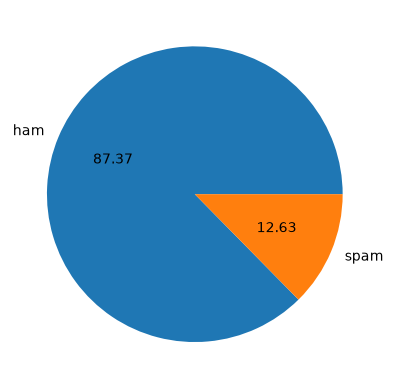

In [22]:
# For better representation above we can use pie-chart using Matplotlib
import matplotlib.pyplot as plt

plt.pie(df['label'].value_counts(), labels=['ham','spam'],autopct="%0.2f")
plt.show()

Data is imbalanced

### NLTK
NLTK (Natural Language Toolkit) is a Python library used for Natural Language Processing (NLP). It provides tools and datasets for processing, analyzing, and understanding human language (text).
Raw text is usually messy.

Example:

**URGENT!!! Click here immediately to claim your prize.**

Before using this text for machine learning, we need to:

* Convert to lowercase
* Split into words
* Remove punctuation
* Remove common words (e.g., "the", "is", "and")
* Reduce words to their root form

NLTK provides built-in tools for all of these tasks.

In [35]:
import nltk


In [24]:
nltk.download('punkt')   # downloads the Punkt tokenizer model that NLTK uses to split text into sentences and words.

[nltk_data] Downloading package punkt to /home/sdhakal/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [37]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     /home/sdhakal/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

**Punkt** is a pre-trained tokenization model.

It has learned punctuation rules, such as:

* A period (.) usually ends a sentence.
* A comma (,) separates words or phrases.
* Question marks (?) and exclamation marks (!) indicate sentence boundaries.

This helps NLTK correctly split text.

In [27]:
# Create a new column 'num_characters' containing the number of characters in each message.
df['num_characters'] = df['Message'].apply(len)

In [28]:
df.head()

,label,Message,num_characters
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


 Calculate the number of word tokens in each message and apply it to every row.

In [33]:
# apply() runs a function on every row in the column.
# x represent one message at a time. Eg: x = "Hello, how are you?"
# nltk.word_tokenize(x) : This splits the message into individual tokens (words and punctuation).
''' Eg:
x = "Hello, how are you?"
To ['Hello', ',', 'how', 'are', 'you', '?']
len() => Counts how many tokens are returned.
'''
df['num_words'] = df['Message'].apply(lambda x : len(nltk.wordpunct_tokenize(x)))

# Also create a new column 'num_words' containing the number of words in each message.

In [32]:
df.head()

,label,Message,num_characters,num_words
0,0,"Go until jurong point, crazy.. Available only ...",111,24
1,0,Ok lar... Joking wif u oni...,29,8
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,39
3,0,U dun say so early hor... U c already then say...,49,13
4,0,"Nah I don't think he goes to usf, he lives aro...",61,16


Also counting the number of sentences in each message

In [38]:

df['num_sentences'] = df['Message'].apply(lambda x : len(nltk.sent_tokenize(x)))

In [39]:
df.head()

,label,Message,num_characters,num_words,num_sentences
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,39,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,16,1


Generates descriptive statistics for the selected numerical columns.

In [40]:
df[['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,5169.000000,5169.000000,5169.000000
mean,78.977945,19.202747,1.965564
std,58.236293,13.963696,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,28.000000,2.000000
max,910.000000,210.000000,38.000000


| Statistic                    | Description                                                                                               |
| ---------------------------- | --------------------------------------------------------------------------------------------------------- |
| **Count**                    | There are **5,169** messages in the dataset.                                                              |
| **Mean**                     | On average, a message contains **79 characters**, **19 words**, and **2 sentences**.                      |
| **Std (Standard Deviation)** | Shows the variation in message lengths. Higher values indicate that message lengths vary considerably.    |
| **Min**                      | The shortest message has **2 characters**, **1 word**, and **1 sentence**.                                |
| **25% (Q1)**                 | 25% of messages contain **36 or fewer characters**, **9 or fewer words**, and **1 sentence**.             |
| **50% (Median)**             | Half of the messages have **60 or fewer characters**, **15 or fewer words**, and **1 sentence**.          |
| **75% (Q3)**                 | 75% of messages contain **117 or fewer characters**, **28 or fewer words**, and **2 or fewer sentences**. |
| **Max**                      | The longest message has **910 characters**, **210 words**, and **38 sentences**.                          |


Similarly generating separately for  ham and spam message separately

In [44]:
#  For Ham message
df[df['label'] == 0][['num_characters','num_words','num_sentences']].describe()


,num_characters,num_words,num_sentences
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.448627,1.820195
std,56.358207,13.769106,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,9.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,210.000000,38.000000


In [47]:
#  For Spam message
df[df['label'] == 1][['num_characters','num_words','num_sentences']].describe()


,num_characters,num_words,num_sentences
count,653.000000,653.000000,653.000000
mean,137.891271,31.333844,2.970904
std,30.137753,7.997049,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,28.000000,2.000000
50%,149.000000,33.000000,3.000000
75%,157.000000,36.000000,4.000000
max,224.000000,49.000000,9.000000


### Seaborn
being used to visualize the distribution of message lengths.

In [50]:
import seaborn as sns

<Axes: xlabel='num_characters', ylabel='Count'>

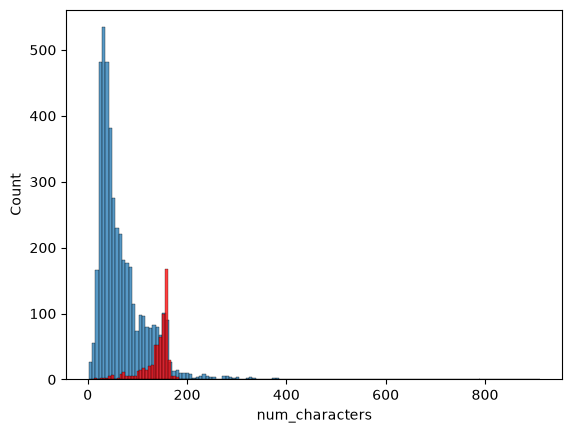

In [52]:
# Compare and plot the distribution of character counts for ham and spam messages.
sns.histplot(df[df['label'] == 0]['num_characters'])
sns.histplot(df[df['label'] == 1]['num_characters'],color='Red')

<Axes: xlabel='num_words', ylabel='Count'>

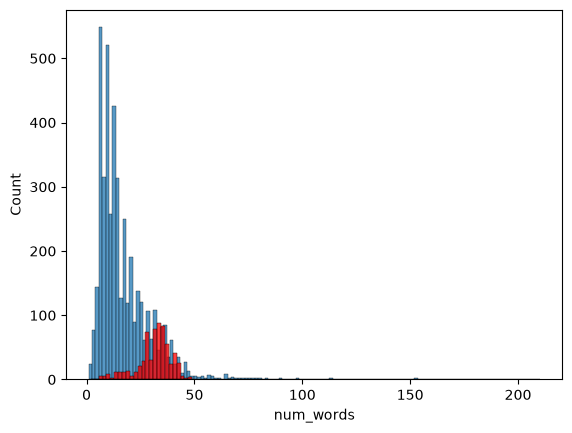

In [53]:
# Compare and plot the distribution of words counts for ham and spam messages.
sns.histplot(df[df['label'] == 0]['num_words'])
sns.histplot(df[df['label'] == 1]['num_words'],color='Red')

### "How does every numerical feature relate to every other feature?"
**What is a Pair Plot?**

A pair plot is a collection of plots that shows:

* The distribution of each numerical feature (diagonal plots).
* The relationship between every pair of numerical features (scatter plots).
* Different classes using colors (hue).


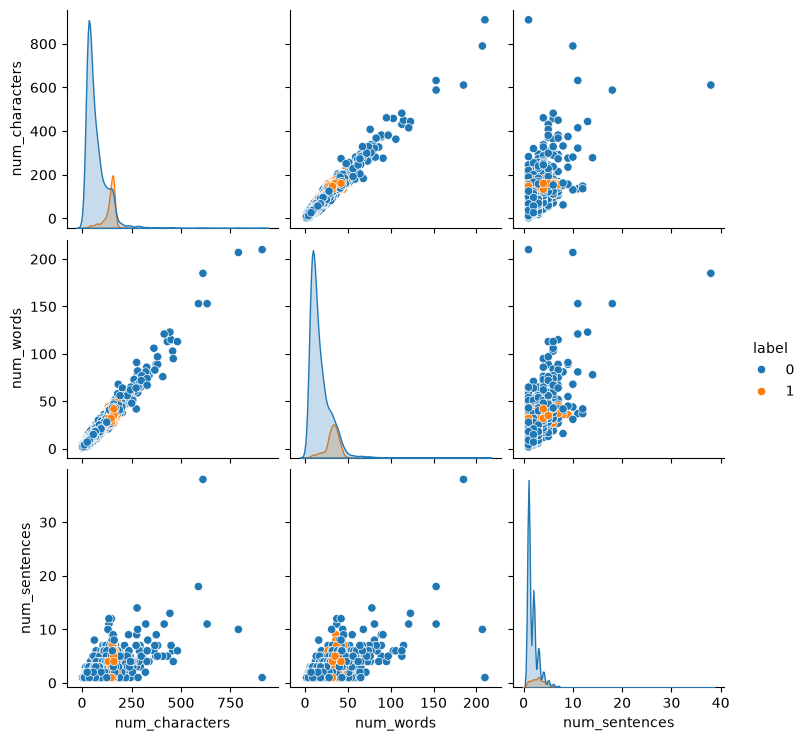

In [55]:
sns.pairplot(df,hue='label' )

> This pair plot helps us understand the relationship between the **number of characters, words, and sentences** in the SMS messages. The diagonal graphs show how these values are distributed, while the scatter plots compare each feature with the others. We can see that messages with more characters usually have more words. Spam messages (orange) generally tend to be longer than ham messages (blue), although there is some overlap. The plot also shows a few unusually long messages, which appear as outliers.


<Axes: >

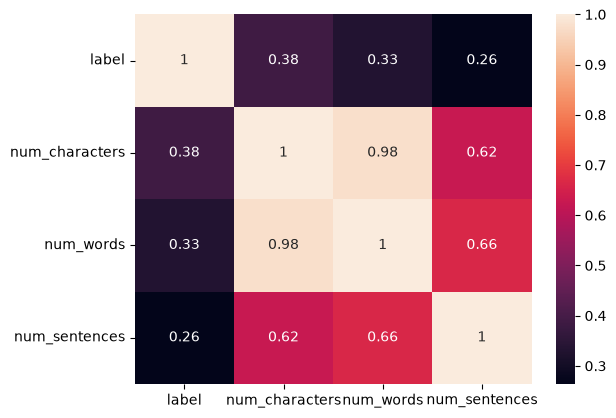

In [58]:
sns.heatmap(df[['label', 'num_characters', 'num_words', 'num_sentences']].corr(),annot=True)